###  Reward Functions

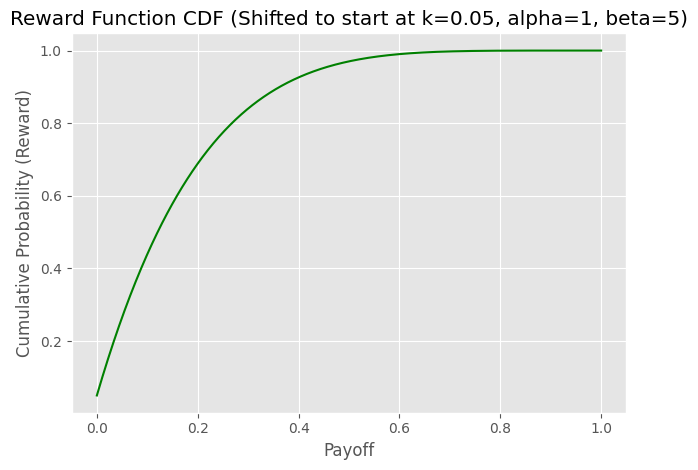

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
plt.style.use('ggplot')

def plot_valuation_and_reward_distributions(alpha_value, beta_value, alpha_reward, beta_reward, k):
    x = np.linspace(0, 1, 1000)
    valuation_pdf = beta.pdf(x, alpha_value, beta_value)
    reward_cdf = k + (1 - k) * beta.cdf(x, alpha_reward, beta_reward)  # Rescale CDF to start at k
    plt.plot(x, reward_cdf, color='green')
    plt.title(f'Reward Function CDF (Shifted to start at k={k}, alpha={alpha_reward}, beta={beta_reward})')
    plt.xlabel('Payoff')
    plt.ylabel('Cumulative Probability (Reward)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example usage with k affecting the y-axis (e.g., k = 0.3)
plot_valuation_and_reward_distributions(alpha_value=1, beta_value=10, alpha_reward=1, beta_reward=5, k=0.05)


# Training

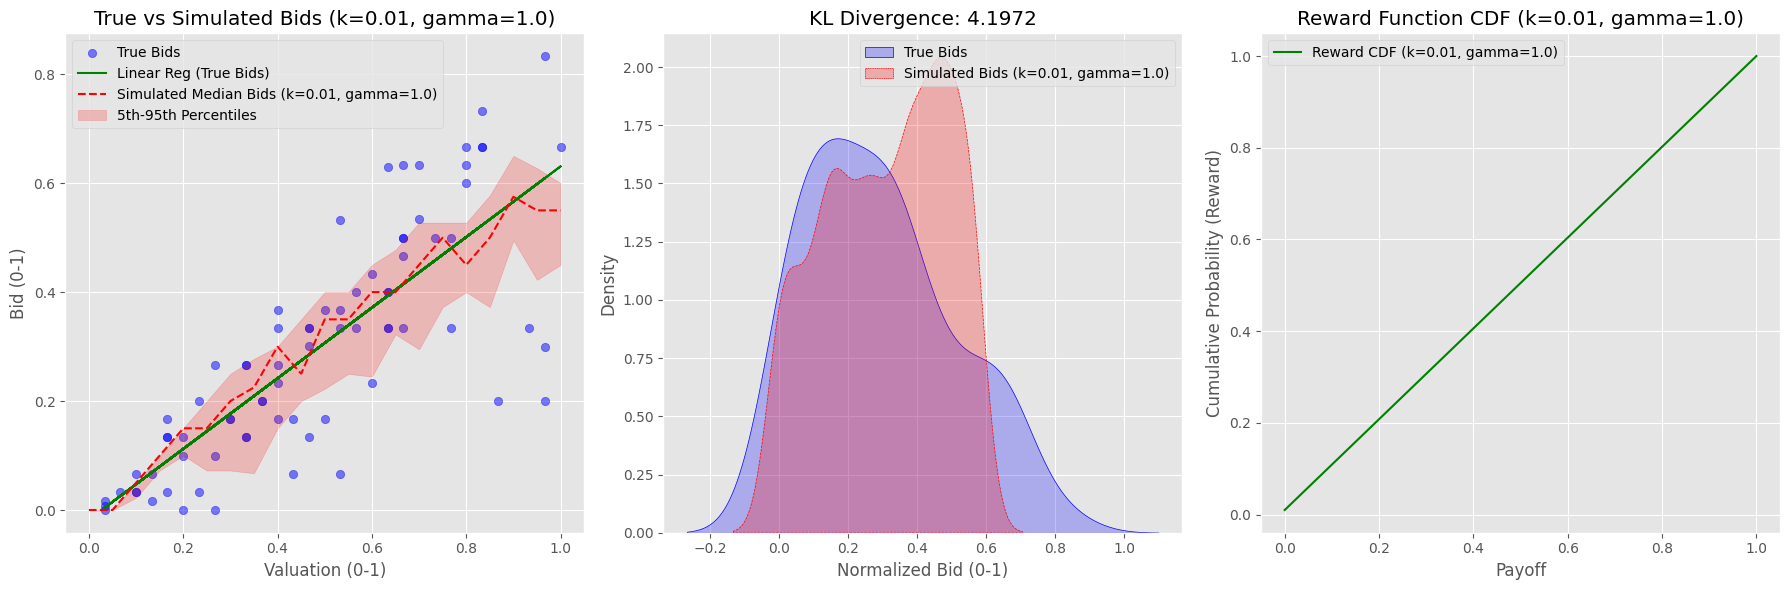

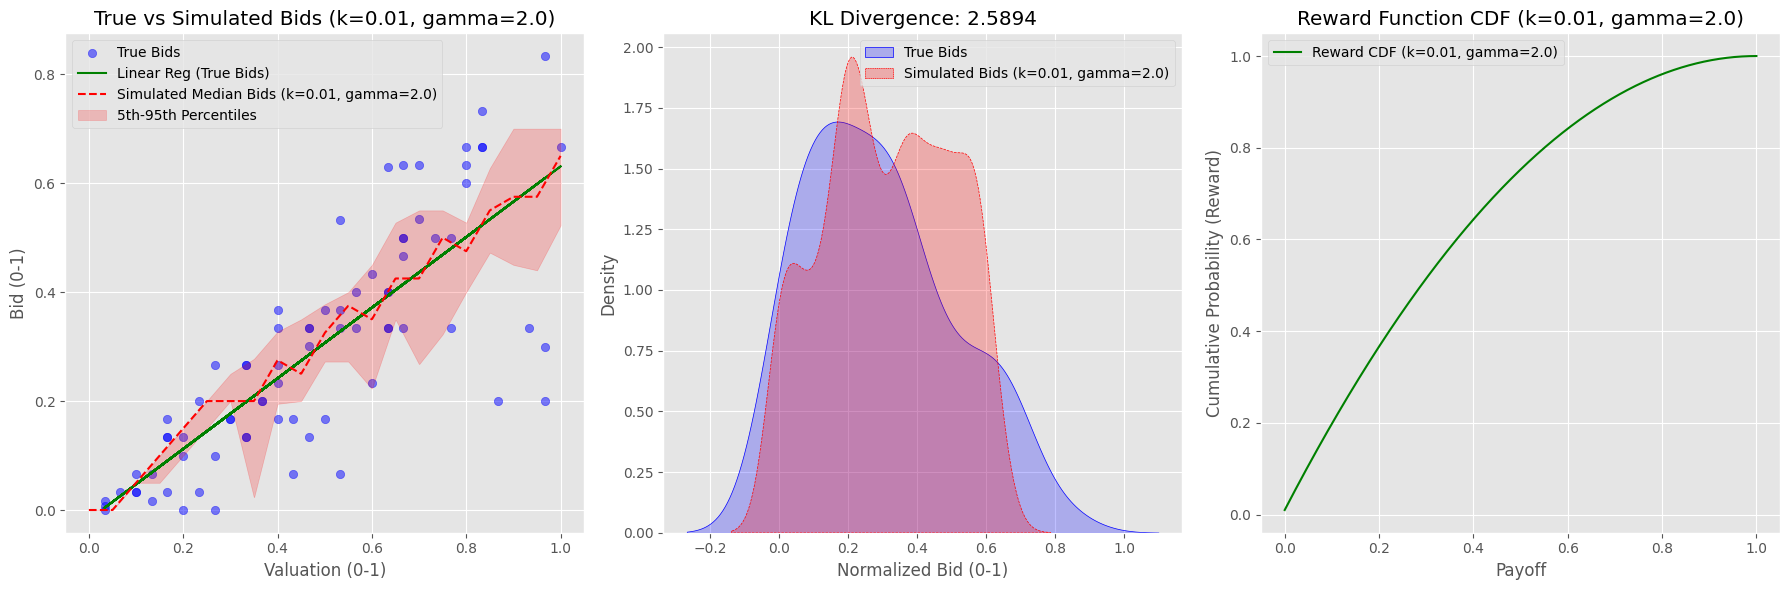

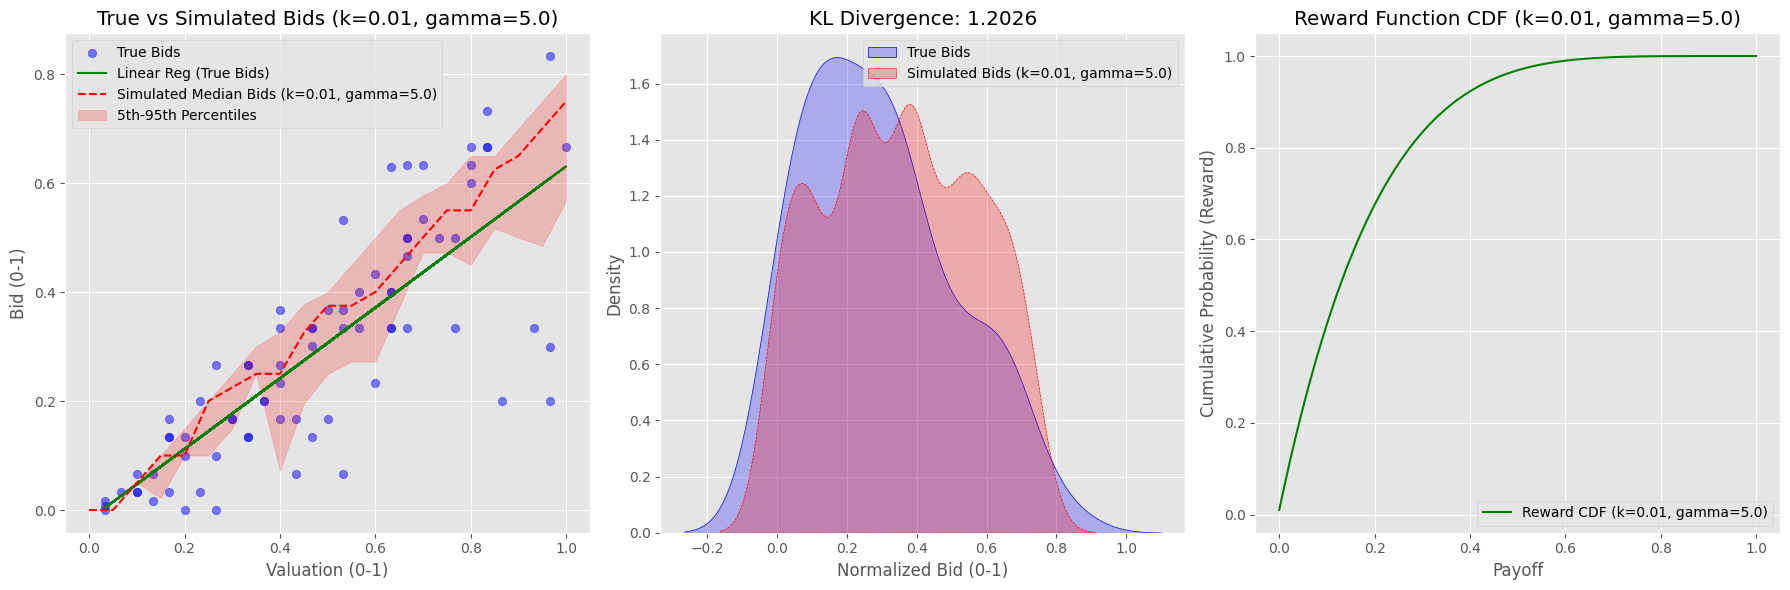

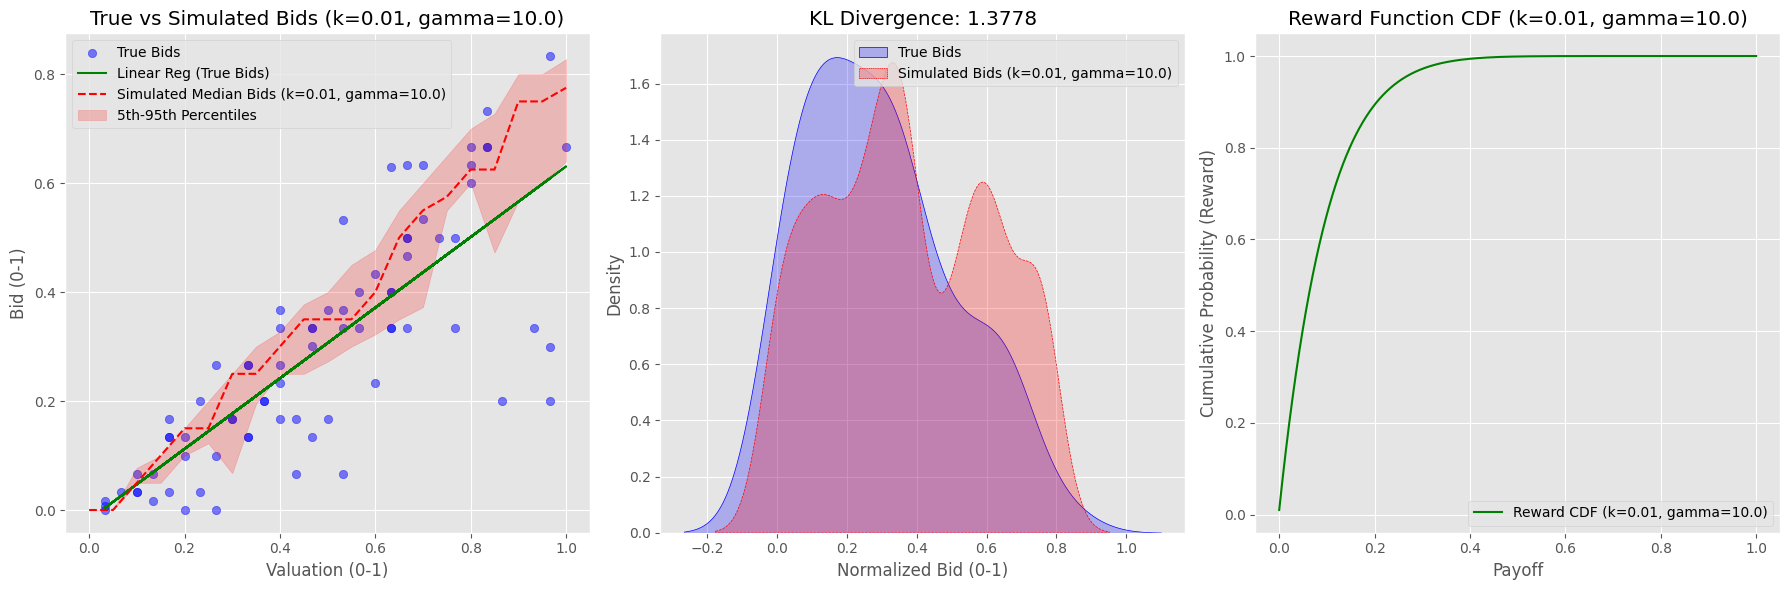

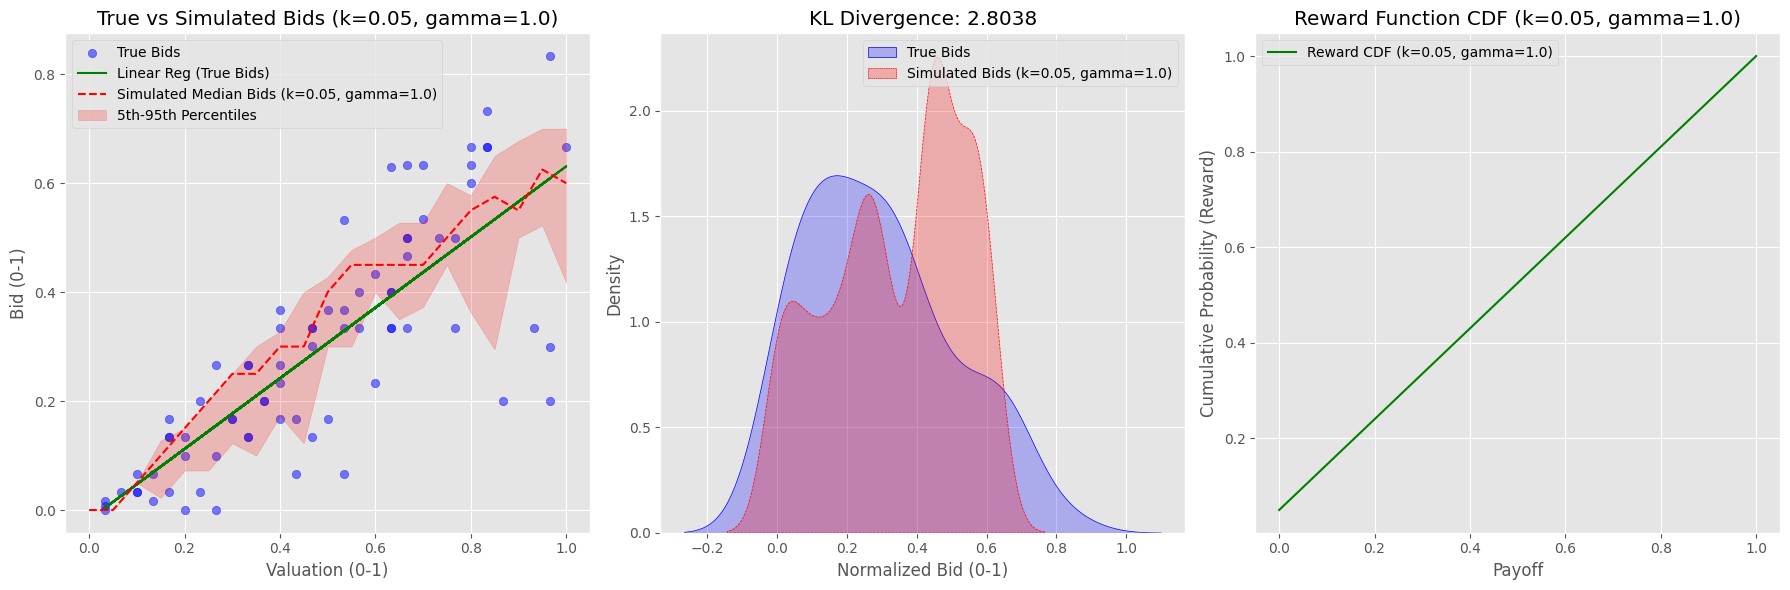

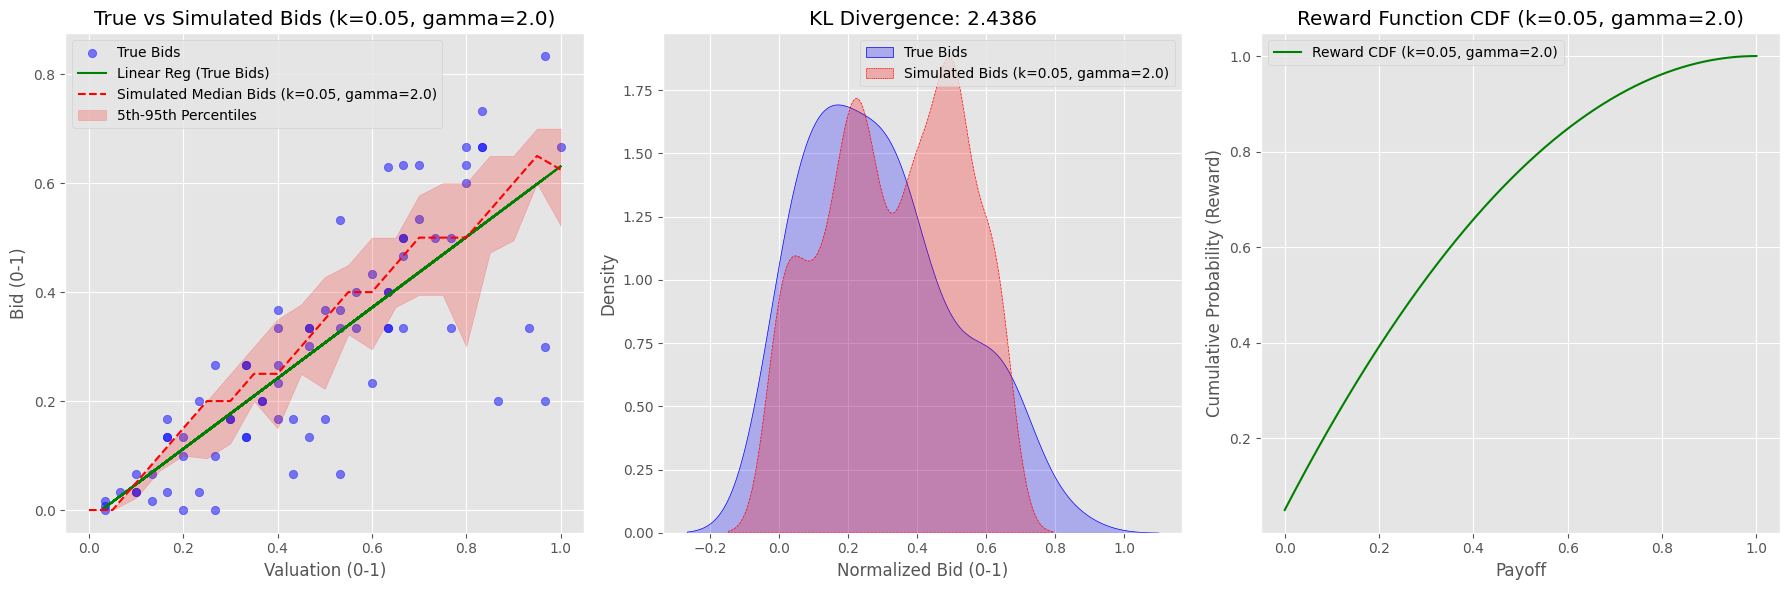

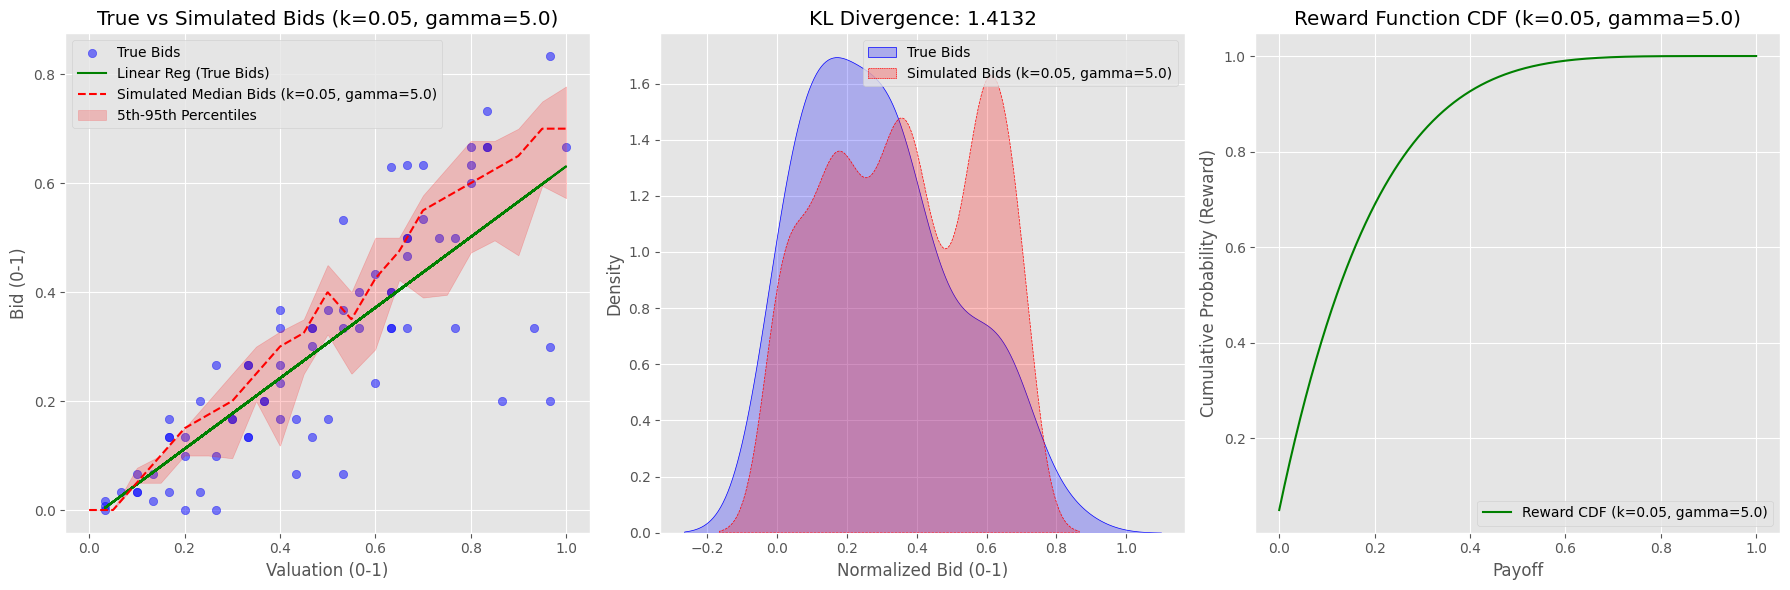

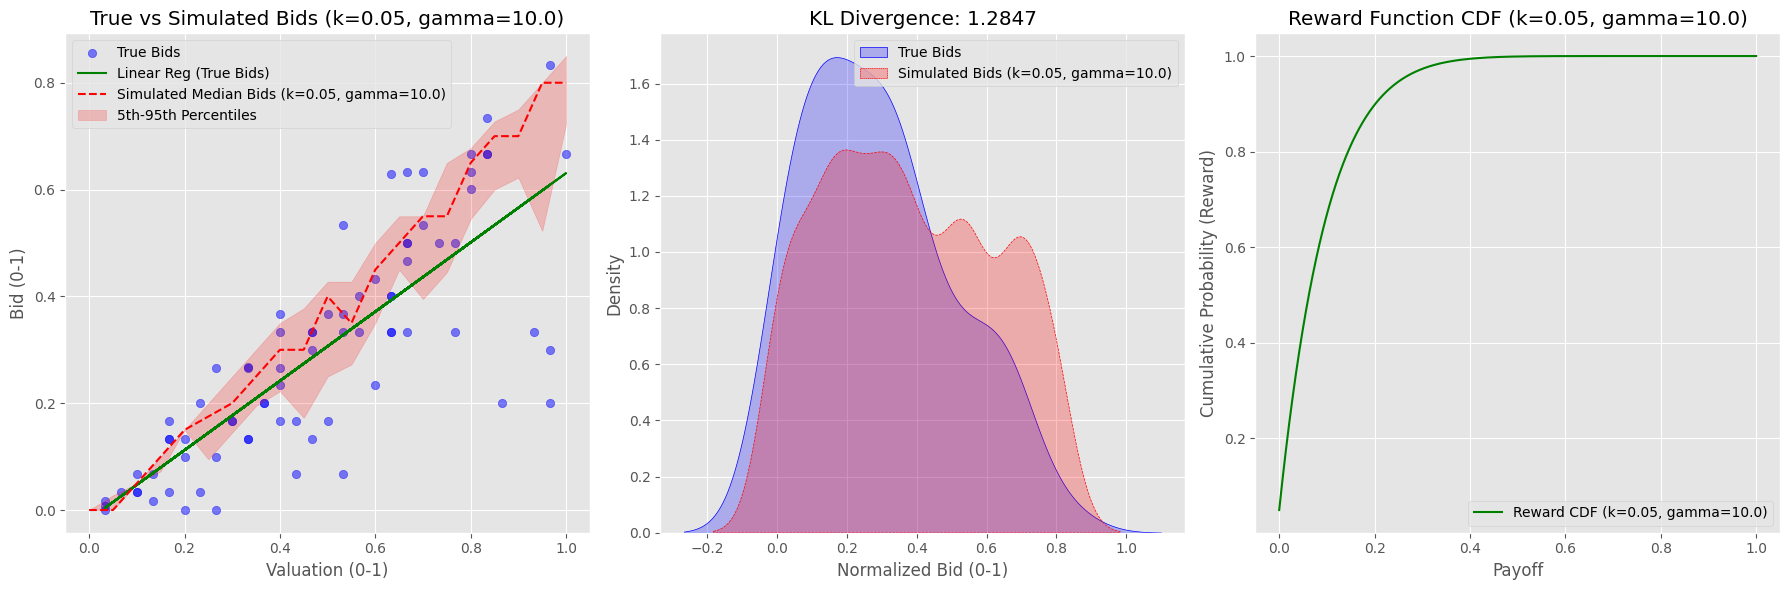

Best parameters: k=0.05, gamma=5.0
Sampled bid for valuation 0.5: 0.35000000000000003


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, beta as beta_dist, entropy, norm
import statsmodels.api as sm
from scipy.interpolate import interp1d

# ========== Section 1: Data Loading and Normalization for First Price Auction ==========

def load_and_clean_first_price_data(filepath):
    data = pd.read_csv(filepath)
    cleaned_data = data[(data['matched_info'] == 'yes') & 
                        (data['bid_fp'] >= 0) &
                        (data['bid_fp'] <= data['value_fp']) &
                        (data['value_fp'] <= 30) &
                        (data['even_month'] == 'no') &
                        (data['value_fp'] >= 0)].copy()
    cleaned_data['bid_fp'] = cleaned_data['bid_fp'] / 30  # Normalize to 0-1 range
    cleaned_data['value_fp'] = cleaned_data['value_fp'] / 30  # Normalize to 0-1 range
    return cleaned_data

# ========== Section 2: Q-Learning Agent with Epsilon Decay and Auction Setup ==========

class QLearningAgent:
    def __init__(self, valuation_distribution, action_min=0, action_max=1, granularity=21, epsilon=0.99, alpha=0.1, total_rounds=10000):
        self.valuation_distribution = valuation_distribution
        self.actions = np.linspace(action_min, action_max, granularity)
        self.epsilon = epsilon
        self.alpha = alpha
        self.total_rounds = total_rounds
        self.granularity = granularity
        self.q_values = np.zeros((granularity, len(self.actions)))
        self.valuation = self.valuation_distribution()
        self.state = self.get_state(self.valuation)

    def epsilon_decay(self, current_round):
        if current_round < 0.66 * self.total_rounds:
            self.epsilon = 0.99 - (0.94 * current_round / (0.66 * self.total_rounds))
        else:
            self.epsilon = 0.05

    def get_state(self, valuation):
        bin_centers = np.linspace(0, 1, len(self.q_values))
        return np.argmin(np.abs(bin_centers - valuation))
    
    def refresh_valuation(self):
        self.valuation = self.valuation_distribution()
        self.state = self.get_state(self.valuation)
    
    def choose_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.actions)
        return self.actions[np.argmax(self.q_values[self.state])]

    def update_q_values(self, chosen_action, reward):
        action_index = np.where(self.actions == chosen_action)[0][0]
        self.q_values[self.state, action_index] += self.alpha * (reward - self.q_values[self.state, action_index])

    def feedback(self, reward, action):
        self.update_q_values(action, reward)

class SingleSidedAuction:
    def __init__(self, agents, price_floor=0, price_ceiling=1, payment_rule=None, k=0.1, gamma=1.0, alpha=1.0):
        self.agents = agents
        self.price_floor = price_floor
        self.price_ceiling = price_ceiling
        self.payment_rule = payment_rule
        self.k = k  # Reward function parameter k
        self.gamma = gamma  # Reward function parameter gamma
        self.alpha = alpha  # Fixed alpha for Beta CDF

    def run_auction(self, current_round):
        for agent in self.agents:
            agent.epsilon_decay(current_round)
            agent.refresh_valuation()
        
        bids = [max(self.price_floor, min(agent.choose_action(), self.price_ceiling)) for agent in self.agents]
        winner_index, payment = self.payment_rule(bids)
        
        for idx, agent in enumerate(self.agents):
            if idx == winner_index:
                payoff = agent.valuation - payment
                reward = self.k + (1 - self.k) * beta_dist.cdf(payoff, self.alpha, self.gamma) if payoff >= 0 else payoff
                agent.feedback(reward, bids[idx])
            else:
                agent.feedback(0, bids[idx])

# ========== Section 3: First Price Auction Simulation with Percentiles ==========

def run_monte_carlo_simulation(agents, auction, num_simulations=1, num_rounds=10000):
    all_bids_for_valuations = [[] for _ in range(len(agents))]
    for sim in range(num_simulations):
        for round_num in range(num_rounds):
            auction.run_auction(round_num)
        for i, agent in enumerate(agents):
            avg_bids_for_valuation = [agent.actions[np.argmax(agent.q_values[state])] for state in range(agent.granularity)]
            all_bids_for_valuations[i].append(avg_bids_for_valuation)

    percentiles = {}
    for i in range(len(agents)):
        avg_bids_for_agent = np.array(all_bids_for_valuations[i])
        percentiles[i] = {
            "5th": np.percentile(avg_bids_for_agent, 5, axis=0),
            "median": np.median(avg_bids_for_agent, axis=0),
            "95th": np.percentile(avg_bids_for_agent, 95, axis=0),
        }
    return percentiles

def sample_bid_given_valuation(percentiles, valuation, agent_idx):
    granularity = len(percentiles[agent_idx]["median"])
    valuation_idx = int(valuation * (granularity - 1))  # Find closest index
    mean = percentiles[agent_idx]["median"][valuation_idx]
    low = percentiles[agent_idx]["5th"][valuation_idx]
    high = percentiles[agent_idx]["95th"][valuation_idx]
    
    # Sample bid using normal distribution centered at mean, constrained by 5th and 95th percentiles
    std_dev = (high - low) / 4  # Approximation: use range as 4 standard deviations
    sampled_bid = np.clip(norm.rvs(loc=mean, scale=std_dev), low, high)
    
    return sampled_bid

# ========== Section 4: KL Divergence Calculation and Search for Best K/Gamma ==========

def calculate_kl_divergence(true_bids, simulated_bids):
    true_hist, bin_edges = np.histogram(true_bids, bins=50, density=True, range=(0, 1))
    sim_hist, _ = np.histogram(simulated_bids, bins=bin_edges, density=True, range=(0, 1))
    kl_divergence = entropy(true_hist + 1e-10, sim_hist + 1e-10)
    return kl_divergence

def find_best_k_gamma(filepath, agents, auction, k_values, gamma_values, num_simulations=10, num_rounds=50000):
    best_kl = float('inf')
    best_k, best_gamma = None, None

    true_data = load_and_clean_first_price_data(filepath)
    true_bids = true_data['bid_fp'].values
    true_valuations = true_data['value_fp'].values

    for k in k_values:
        for gamma in gamma_values:
            auction.k = k
            auction.gamma = round(gamma, 2)
            percentiles = run_monte_carlo_simulation(agents, auction, num_simulations=num_simulations, num_rounds=num_rounds)

            simulated_bids = percentiles[0]["median"]
            kl_divergence = calculate_kl_divergence(true_bids, simulated_bids)

            if kl_divergence < best_kl:
                best_kl = kl_divergence
                best_k, best_gamma = k, gamma

            plot_all_three(true_valuations, true_bids, percentiles, k, gamma, auction.alpha)

    return best_k, best_gamma


def first_price_rule(bids):
    # The highest bid wins in a first-price auction
    max_bid = np.max(bids)
    winner_candidates = np.where(bids == max_bid)[0]
    winner = np.random.choice(winner_candidates) if len(winner_candidates) > 1 else winner_candidates[0]
    
    # Payment in a first-price auction is the winning bid
    payment = bids[winner]
    
    return winner, payment

# ========== Section 5: Plot All Three (Bidding Function, Bid Distribution, Reward Function) ==========

def plot_all_three(true_valuations, true_bids, percentiles, k, gamma, alpha):
    x = np.linspace(0, 1, 1000)
    reward_cdf = k + (1 - k) * beta_dist.cdf(x, alpha, gamma)  
    
    interpolated_median_bids = interp1d(np.linspace(0, 1, len(percentiles[0]["median"])), percentiles[0]["median"], kind='linear')(x)
    interpolated_5th_bids = interp1d(np.linspace(0, 1, len(percentiles[0]["5th"])), percentiles[0]["5th"], kind='linear')(x)
    interpolated_95th_bids = interp1d(np.linspace(0, 1, len(percentiles[0]["95th"])), percentiles[0]["95th"], kind='linear')(x)

    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    # Plot 1: True vs Simulated Bids (Bidding Function) with Fan Chart
    axs[0].scatter(true_valuations, true_bids, alpha=0.5, color='blue', label='True Bids')
    X = sm.add_constant(true_valuations)
    model = sm.OLS(true_bids, X).fit()
    reg_line = model.predict(X)
    axs[0].plot(true_valuations, reg_line, color='green', label='Linear Reg (True Bids)')
    axs[0].plot(x, interpolated_median_bids, color='red', linestyle='--', label=f'Simulated Median Bids (k={k}, gamma={gamma})')

    # Fan chart (5th and 95th percentiles)
    axs[0].fill_between(x, interpolated_5th_bids, interpolated_95th_bids, color='red', alpha=0.2, label='5th-95th Percentiles')

    axs[0].set_xlabel('Valuation (0-1)')
    axs[0].set_ylabel('Bid (0-1)')
    axs[0].set_title(f'True vs Simulated Bids (k={k}, gamma={gamma})')
    axs[0].legend()
    axs[0].grid(True)

    # Plot 2: KDE of True and Simulated Bids + KL Divergence
    sns.kdeplot(true_bids, label='True Bids', color='blue', fill=True, ax=axs[1])
    sns.kdeplot(interpolated_median_bids, label=f'Simulated Bids (k={k}, gamma={gamma})', color='red', linestyle='--', fill=True, ax=axs[1])
    axs[1].set_xlabel('Normalized Bid (0-1)')
    axs[1].set_ylabel('Density')
    kl_divergence = calculate_kl_divergence(true_bids, interpolated_median_bids)
    axs[1].set_title(f'KL Divergence: {kl_divergence:.4f}')
    axs[1].legend()
    axs[1].grid(True)

    # Plot 3: Reward Function CDF
    axs[2].plot(x, reward_cdf, color='green', label=f'Reward CDF (k={k}, gamma={gamma})')
    axs[2].set_xlabel('Payoff')
    axs[2].set_ylabel('Cumulative Probability (Reward)')
    axs[2].set_title(f'Reward Function CDF (k={k}, gamma={gamma})')
    axs[2].grid(True)
    axs[2].legend()

    plt.tight_layout()
    plt.show()

# ========== Example Usage for First Price Auction ==========

filepath = 'clean_kaplan_data.csv'  # Update with the correct path to your data file

data = load_and_clean_first_price_data(filepath)
valuations = data['value_fp'].values

kde = gaussian_kde(valuations, bw_method='scott')
agents = [QLearningAgent(valuation_distribution=lambda: kde.resample(1)[0][0]) for _ in range(2)]
agents = [QLearningAgent(valuation_distribution=lambda: np.random.uniform(0, 1)) for _ in range(2)]

auction = SingleSidedAuction(agents, payment_rule=first_price_rule, k=0.1, gamma=1.0, alpha=1.0)

k_values = [0.01, 0.05]
gamma_values = [1.0, 2.0, 5.0, 10.0]

best_k, best_gamma = find_best_k_gamma(filepath, agents, auction, k_values, gamma_values)
print(f"Best parameters: k={best_k}, gamma={best_gamma}")

# Example: Sampling a bid for a given valuation
valuation = 0.5
sampled_bid = sample_bid_given_valuation(run_monte_carlo_simulation(agents, auction), valuation, agent_idx=0)
print(f"Sampled bid for valuation {valuation}: {sampled_bid}")


# Second Price

0
1
2
3
4
5
6
7
8
9


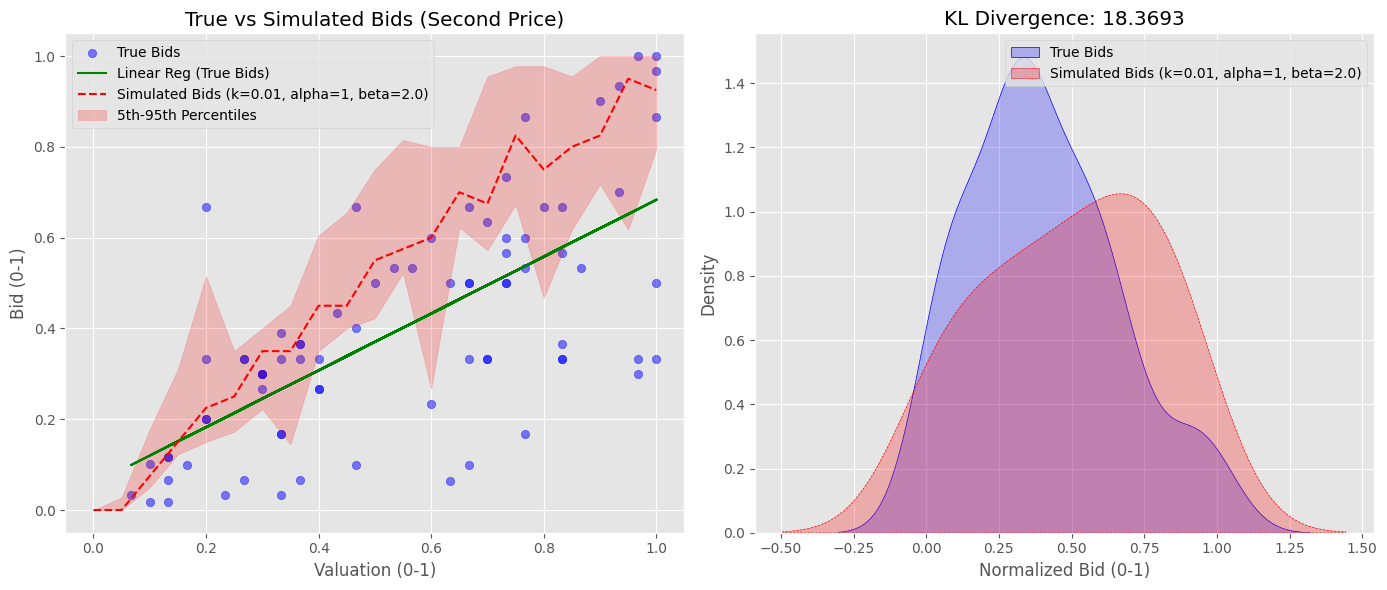

Learned Bidding Function (Second Price Auction): {'median': [0.0, 0.05, 0.05, 0.15000000000000002, 0.2, 0.35000000000000003, 0.2, 0.35000000000000003, 0.35000000000000003, 0.45, 0.75, 0.6000000000000001, 0.6000000000000001, 0.6000000000000001, 0.65, 0.9, 0.55, 0.8, 0.8, 0.55, 1.0], '5th': array([0.    , 0.    , 0.05  , 0.1225, 0.15  , 0.1725, 0.2225, 0.145 ,
       0.35  , 0.4   , 0.4225, 0.5225, 0.2675, 0.6225, 0.5725, 0.6725,
       0.4675, 0.6175, 0.7175, 0.6175, 0.795 ]), '95th': array([0.    , 0.0275, 0.1775, 0.31  , 0.515 , 0.35  , 0.4   , 0.45  ,
       0.605 , 0.655 , 0.75  , 0.815 , 0.8   , 0.8   , 0.955 , 0.9775,
       0.9775, 0.955 , 1.    , 1.    , 1.    ])}


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, beta as beta_dist, entropy, norm
import statsmodels.api as sm

# ========== Section 1: Data Loading and Normalization for Second Price Auction ==========

def load_and_clean_second_price_data(filepath):
    data = pd.read_csv(filepath)
    cleaned_data = data[(data['matched_info'] == 'yes') & 
                        (data['bid_sp'] >= 0) &
                        (data['bid_sp'] <= 30) &
                        (data['even_month'] == 'no') &
                        (data['value_sp'] <= 30) &
                        (data['value_sp'] >= 0)].copy()
    cleaned_data['bid_sp'] = cleaned_data['bid_sp'] / 30  # Normalize to 0-1 range
    cleaned_data['value_sp'] = cleaned_data['value_sp'] / 30  # Normalize to 0-1 range
    return cleaned_data

# ========== Section 2: Q-Learning Agent with Epsilon Decay and Auction Setup ==========

class QLearningAgent:
    def __init__(self, valuation_distribution, action_min=0, action_max=1, granularity=21, epsilon=0.99, alpha=0.1, total_rounds=10000):
        self.valuation_distribution = valuation_distribution
        self.actions = np.linspace(action_min, action_max, granularity)
        self.epsilon = epsilon
        self.alpha = alpha
        self.total_rounds = total_rounds
        self.granularity = granularity
        self.q_values = np.zeros((granularity, len(self.actions)))
        self.valuation = self.valuation_distribution()
        self.state = self.get_state(self.valuation)

    def epsilon_decay(self, current_round):
        if current_round < 0.66 * self.total_rounds:
            self.epsilon = 0.99 - (0.94 * current_round / (0.66 * self.total_rounds))
        else:
            self.epsilon = 0.05

    def get_state(self, valuation):
        bin_centers = np.linspace(0, 1, len(self.q_values))
        return np.argmin(np.abs(bin_centers - valuation))
    
    def refresh_valuation(self):
        self.valuation = self.valuation_distribution()
        self.state = self.get_state(self.valuation)
    
    def choose_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.actions)
        return self.actions[np.argmax(self.q_values[self.state])]

    def update_q_values(self, chosen_action, reward):
        action_index = np.where(self.actions == chosen_action)[0][0]
        self.q_values[self.state, action_index] += self.alpha * (reward - self.q_values[self.state, action_index])

    def feedback(self, reward, action):
        self.update_q_values(action, reward)

class SecondPriceAuction:
    def __init__(self, agents, price_floor=0, price_ceiling=1, payment_rule=None, k=0.1, alpha=1.0, beta=1.0):
        self.agents = agents
        self.price_floor = price_floor
        self.price_ceiling = price_ceiling
        self.payment_rule = payment_rule
        self.k = k  # Reward function parameter k
        self.alpha = alpha
        self.beta = beta

    def run_auction(self, current_round):
        for agent in self.agents:
            agent.epsilon_decay(current_round)
            agent.refresh_valuation()
        
        bids = [max(self.price_floor, min(agent.choose_action(), self.price_ceiling)) for agent in self.agents]
        winner_index, payment = self.payment_rule(bids)
        
        for idx, agent in enumerate(self.agents):
            if idx == winner_index:
                payoff = agent.valuation - payment
                reward = self.k + (1 - self.k) * beta_dist.cdf(payoff, self.alpha, self.beta) if payoff >= 0 else payoff
                agent.feedback(reward, bids[idx])
            else:
                agent.feedback(0, bids[idx])



# ========== Section 3: Second Price Auction Rule ==========

def second_price_rule(bids):
    max_bid = np.max(bids)
    winner_candidates = np.where(bids == max_bid)[0]
    winner = np.random.choice(winner_candidates) if len(winner_candidates) > 1 else winner_candidates[0]
    second_highest_bid = np.partition(bids, -2)[-2]  # Second-highest bid for payment
    return winner, second_highest_bid

def run_monte_carlo_simulation(agents, auction, num_simulations=30, num_rounds=10000):
    all_bids_for_valuations = [[] for _ in range(len(agents))]
    learned_bidding_functions = [[] for _ in range(len(agents))]  # Store learned bidding functions
    
    for sim in range(num_simulations):
        print(sim)
        for round_num in range(num_rounds):
            auction.run_auction(round_num)
        
        for i, agent in enumerate(agents):
            avg_bids_for_valuation = [agent.actions[np.argmax(agent.q_values[state])] for state in range(agent.granularity)]
            all_bids_for_valuations[i].append(avg_bids_for_valuation)
            learned_bidding_functions[i] = avg_bids_for_valuation  # Store the learned function

    percentiles = {}
    for i in range(len(agents)):
        avg_bids_for_agent = np.array(all_bids_for_valuations[i])
        percentiles[i] = {
            "5th": np.percentile(avg_bids_for_agent, 5, axis=0),
            "median": np.median(avg_bids_for_agent, axis=0),
            "95th": np.percentile(avg_bids_for_agent, 95, axis=0),
        }
    return percentiles, learned_bidding_functions

def sample_bid_given_valuation(percentiles, valuation, agent_idx):
    granularity = len(percentiles[agent_idx]["median"])
    valuation_idx = int(valuation * (granularity - 1))  # Find closest index
    mean = percentiles[agent_idx]["median"][valuation_idx]
    low = percentiles[agent_idx]["5th"][valuation_idx]
    high = percentiles[agent_idx]["95th"][valuation_idx]
    
    # Sample bid using normal distribution centered at mean, constrained by 5th and 95th percentiles
    std_dev = (high - low) / 4  # Approximation: use range as 4 standard deviations
    sampled_bid = np.clip(norm.rvs(loc=mean, scale=std_dev), low, high)
    
    return sampled_bid

# ========== Section 4: Plotting and Extracting the Learned Bidding Function ==========

def plot_second_price_simulation(filepath, agents, auction, best_k, best_alpha, best_beta, num_simulations=10, num_rounds=50000):
    # Load and clean second-price auction data
    true_data = load_and_clean_second_price_data(filepath)
    true_bids = true_data['bid_sp'].values
    true_valuations = true_data['value_sp'].values

    # Run simulation with the best k, alpha, and beta values
    auction.k = best_k
    auction.alpha = best_alpha
    auction.beta = best_beta
    percentiles, learned_bidding_functions = run_monte_carlo_simulation(agents, auction, num_simulations=num_simulations, num_rounds=num_rounds)

    # Simulated bids and valuations (normalized)
    simulated_bids = percentiles[0]["median"]
    simulated_valuations = np.linspace(0, 1, len(simulated_bids))

    # Create a 1x2 grid of plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot A: True Bids vs True Valuations and Simulated Bidding Function (Second Price) with Fan Chart
    axes[0].scatter(true_valuations, true_bids, alpha=0.5, color='blue', label='True Bids')
    
    # Add linear regression line for true bids vs true valuations
    X = sm.add_constant(true_valuations)
    model = sm.OLS(true_bids, X).fit()
    reg_line = model.predict(X)
    axes[0].plot(true_valuations, reg_line, color='green', label='Linear Reg (True Bids)')

    # Plot simulated bids vs valuations
    axes[0].plot(simulated_valuations, simulated_bids, color='red', linestyle='--', label=f'Simulated Bids (k={best_k}, alpha={best_alpha}, beta={best_beta})')

    # Fan chart (5th and 95th percentiles)
    interpolated_5th_bids = np.interp(simulated_valuations, np.linspace(0, 1, len(percentiles[0]["5th"])), percentiles[0]["5th"])
    interpolated_95th_bids = np.interp(simulated_valuations, np.linspace(0, 1, len(percentiles[0]["95th"])), percentiles[0]["95th"])
    axes[0].fill_between(simulated_valuations, interpolated_5th_bids, interpolated_95th_bids, color='red', alpha=0.2, label='5th-95th Percentiles')

    axes[0].set_xlabel('Valuation (0-1)')
    axes[0].set_ylabel('Bid (0-1)')
    axes[0].set_title(f'True vs Simulated Bids (Second Price)')
    axes[0].legend()
    axes[0].grid(True)

    # Plot B: KDE Comparison of Bids and KL Divergence
    sns.kdeplot(true_bids, label='True Bids', color='blue', fill=True, ax=axes[1])
    sns.kdeplot(simulated_bids, label=f'Simulated Bids (k={best_k}, alpha={best_alpha}, beta={best_beta})', color='red', linestyle='--', fill=True, ax=axes[1])
    axes[1].set_xlabel('Normalized Bid (0-1)')
    axes[1].set_ylabel('Density')
    kl_divergence = calculate_kl_divergence(true_bids, simulated_bids)
    axes[1].set_title(f'KL Divergence: {kl_divergence:.4f}')
    axes[1].legend()
    axes[1].grid(True)

    # Show the 1x2 grid of graphs
    plt.tight_layout()
    plt.show()

    # Return the learned bidding function (median), and 5th and 95th percentiles
    return {
        'median': learned_bidding_functions[0],  # Median bidding function
        '5th': percentiles[0]['5th'],  # 5th percentile bidding function
        '95th': percentiles[0]['95th']  # 95th percentile bidding function
    }

# ========== Example Usage for Second Price Auction ==========

filepath = 'clean_kaplan_data.csv'  # Update with the correct path to your second-price auction data

# Load true data and fit KDE to valuations from first-price data
data = load_and_clean_first_price_data(filepath)
valuations = data['value_fp'].values  # Valuations already normalized to 0-1

# Fit KDE for valuation distribution
kde = gaussian_kde(valuations, bw_method='scott')

# Create Q-Learning agents using KDE-fitted distribution for valuations
#agents = [QLearningAgent(valuation_distribution=lambda: kde.resample(1)[0][0]) for _ in range(2)]
agents = [QLearningAgent(valuation_distribution=lambda: np.random.uniform(0, 1)) for _ in range(2)]
agents = [QLearningAgent(valuation_distribution=lambda: np.random.uniform(0, 1)) for _ in range(2)]

# Setup auction with second-price rule
best_k = 0.01  # Assuming k was determined from the first-price auction
best_alpha = 1
best_beta = 2.0
auction = SecondPriceAuction(agents, payment_rule=second_price_rule, k=best_k, alpha=best_alpha, beta=best_beta)

# Plot the second-price auction simulation results and extract the learned bidding function
learned_bidding_function_spa = plot_second_price_simulation(filepath, agents, auction, best_k, best_alpha, best_beta)

# Output the learned bidding function
print("Learned Bidding Function (Second Price Auction):", learned_bidding_function_spa)

# All-pay

0
1
2
3
4
5
6
7
8
9


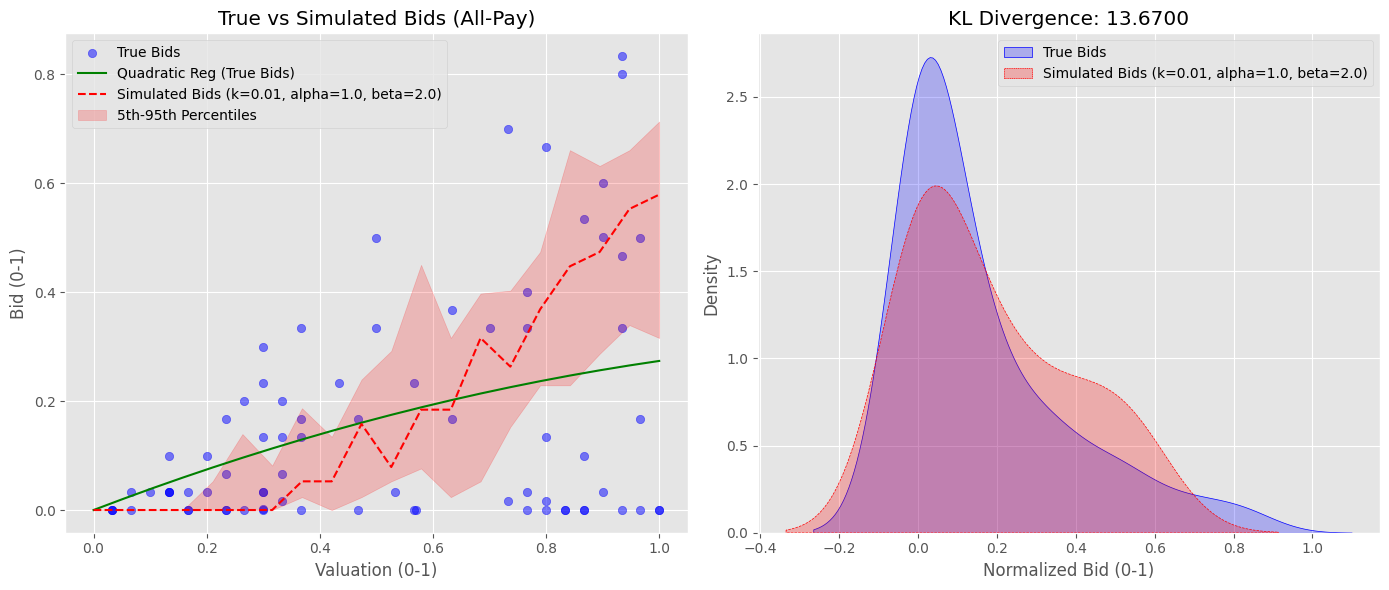

Learned Bidding Function (All-Pay Auction): {'median': [0.0, 0.0, 0.0, 0.0, 0.0, 0.05263157894736842, 0.0, 0.05263157894736842, 0.0, 0.2631578947368421, 0.05263157894736842, 0.10526315789473684, 0.0, 0.42105263157894735, 0.2631578947368421, 0.3157894736842105, 0.5789473684210527, 0.42105263157894735, 0.5789473684210527, 0.6842105263157894], '5th': array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.02368421, 0.        , 0.02368421,
       0.05263158, 0.07631579, 0.02368421, 0.05263158, 0.15263158,
       0.22894737, 0.22894737, 0.28684211, 0.33947368, 0.31578947]), '95th': array([0.        , 0.        , 0.        , 0.        , 0.05263158,
       0.13947368, 0.08157895, 0.18684211, 0.13421053, 0.23947368,
       0.29210526, 0.45      , 0.31578947, 0.39736842, 0.40263158,
       0.47368421, 0.66052632, 0.63157895, 0.66052632, 0.71315789])}


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, beta as beta_dist, entropy
import statsmodels.api as sm

# ========== Section 1: Data Loading and Normalization for All-Pay Auction ==========

def load_and_clean_all_pay_data(filepath):
    # Load and clean all-pay auction data, normalize bids to 0-1 using the max bid value 30
    data = pd.read_csv(filepath)
    cleaned_data = data[(data['matched_info'] == 'yes') & 
                        (data['bid_ap'] >= 0) &
                        (data['bid_ap'] <= data['value_ap']) &
                        (data['even_month'] == 'no') &
                        (data['value_ap'] <= 30) &
                        (data['value_ap'] >= 0)].copy()
    cleaned_data['bid_ap'] = cleaned_data['bid_ap'] / 30  # Normalize to 0-1 range
    cleaned_data['value_ap'] = cleaned_data['value_ap'] / 30  # Normalize to 0-1 range
    return cleaned_data

# ========== Section 2: Q-Learning Agent with Epsilon Decay and Auction Setup ==========

class QLearningAgent:
    def __init__(self, valuation_distribution, action_min=0, action_max=1, granularity=20, epsilon=0.99, alpha=0.1, total_rounds=10000):
        self.valuation_distribution = valuation_distribution
        self.actions = np.linspace(action_min, action_max, granularity)
        self.epsilon = epsilon
        self.alpha = alpha
        self.total_rounds = total_rounds
        self.granularity = granularity
        self.q_values = np.zeros((granularity, len(self.actions)))
        self.valuation = self.valuation_distribution()
        self.state = self.get_state(self.valuation)

    def epsilon_decay(self, current_round):
        if current_round < 0.66 * self.total_rounds:
            self.epsilon = 0.99 - (0.94 * current_round / (0.66 * self.total_rounds))
        else:
            self.epsilon = 0.05

    def get_state(self, valuation):
        bin_centers = np.linspace(0, 1, len(self.q_values))
        return np.argmin(np.abs(bin_centers - valuation))
    
    def refresh_valuation(self):
        self.valuation = self.valuation_distribution()
        self.state = self.get_state(self.valuation)
    
    def choose_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.actions)
        return self.actions[np.argmax(self.q_values[self.state])]

    def update_q_values(self, chosen_action, reward):
        action_index = np.where(self.actions == chosen_action)[0][0]
        self.q_values[self.state, action_index] += self.alpha * (reward - self.q_values[self.state, action_index])

    def feedback(self, reward, action):
        self.update_q_values(action, reward)

class AllPayAuction:
    def __init__(self, agents, price_floor=0, price_ceiling=1, payment_rule=None, k=0.1, alpha=1.0, beta=1.0):
        self.agents = agents
        self.price_floor = price_floor
        self.price_ceiling = price_ceiling
        self.payment_rule = payment_rule
        self.k = k  # Reward function parameter k
        self.alpha = alpha
        self.beta = beta

    def run_auction(self, current_round):
        for agent in self.agents:
            agent.epsilon_decay(current_round)
            agent.refresh_valuation()
        
        bids = [max(self.price_floor, min(agent.choose_action(), self.price_ceiling)) for agent in self.agents]
        winner_index, bids = self.payment_rule(bids)
        
        for idx, agent in enumerate(self.agents):
            payoff = agent.valuation - bids[idx] if idx == winner_index else -bids[idx]  # All players pay their bid
            reward = self.k + (1 - self.k) * beta_dist.cdf(payoff, self.alpha, self.beta) if payoff > 0 else payoff
            agent.feedback(reward, bids[idx])

# ========== Section 3: All-Pay Auction Rule ==========

def all_pay_rule(bids):
    max_bid = np.max(bids)
    winner_candidates = np.where(bids == max_bid)[0]
    winner = np.random.choice(winner_candidates) if len(winner_candidates) > 1 else winner_candidates[0]
    return winner, bids  # Return individual bids for each agent

def run_monte_carlo_simulation(agents, auction, num_simulations=10, num_rounds=50000):
    all_bids_for_valuations = [[] for _ in range(len(agents))]
    learned_bidding_functions = [[] for _ in range(len(agents))]  # Store learned bidding functions

    for sim in range(num_simulations):
        print(sim)
        for round_num in range(num_rounds):
            auction.run_auction(round_num)
        
        for i, agent in enumerate(agents):
            avg_bids_for_valuation = [agent.actions[np.argmax(agent.q_values[state])] for state in range(agent.granularity)]
            all_bids_for_valuations[i].append(avg_bids_for_valuation)
            learned_bidding_functions[i] = avg_bids_for_valuation  # Store the learned function

    percentiles = {}
    for i in range(len(agents)):
        avg_bids_for_agent = np.array(all_bids_for_valuations[i])
        percentiles[i] = {
            "5th": np.percentile(avg_bids_for_agent, 5, axis=0),
            "median": np.median(avg_bids_for_agent, axis=0),
            "95th": np.percentile(avg_bids_for_agent, 95, axis=0),
        }
    return percentiles, learned_bidding_functions

# ========== Section 4: Plotting and Comparing to All-Pay Auction ==========

def plot_all_pay_simulation(filepath, agents, auction, best_k, best_alpha, best_beta, num_simulations=10, num_rounds=50000):
    # Load and clean all-pay auction data
    true_data = load_and_clean_all_pay_data(filepath)
    true_bids = true_data['bid_ap'].values
    true_valuations = true_data['value_ap'].values

    # Run simulation with the best k, alpha, and beta values
    auction.k = best_k
    auction.alpha = best_alpha
    auction.beta = best_beta
    percentiles, learned_bidding_functions = run_monte_carlo_simulation(agents, auction, num_simulations=num_simulations, num_rounds=num_rounds)

    # Simulated bids and valuations (normalized)
    simulated_bids = percentiles[0]["median"]
    simulated_valuations = np.linspace(0, 1, len(simulated_bids))

    # Create a 1x2 grid of plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot A: True Bids vs True Valuations and Simulated Bidding Function (All-Pay)
    axes[0].scatter(true_valuations, true_bids, alpha=0.5, color='blue', label='True Bids')
    
    # Add quadratic regression line (v + v^2) for true bids vs true valuations
    X = np.column_stack([true_valuations, true_valuations ** 2])  # Include v^2 term
    model = sm.OLS(true_bids, X).fit()  # OLS without intercept
    reg_line = model.predict(np.column_stack([simulated_valuations, simulated_valuations ** 2]))  # Predict on v and v^2
    axes[0].plot(simulated_valuations, reg_line, color='green', label='Quadratic Reg (True Bids)')

    # Plot simulated bids vs valuations
    axes[0].plot(simulated_valuations, simulated_bids, color='red', linestyle='--', label=f'Simulated Bids (k={best_k}, alpha={best_alpha}, beta={best_beta})')

    # Fan chart (5th and 95th percentiles)
    interpolated_5th_bids = np.interp(simulated_valuations, np.linspace(0, 1, len(percentiles[0]["5th"])), percentiles[0]["5th"])
    interpolated_95th_bids = np.interp(simulated_valuations, np.linspace(0, 1, len(percentiles[0]["95th"])), percentiles[0]["95th"])
    axes[0].fill_between(simulated_valuations, interpolated_5th_bids, interpolated_95th_bids, color='red', alpha=0.2, label='5th-95th Percentiles')

    axes[0].set_xlabel('Valuation (0-1)')
    axes[0].set_ylabel('Bid (0-1)')
    axes[0].set_title('True vs Simulated Bids (All-Pay)')
    axes[0].legend()
    axes[0].grid(True)

    # Plot B: KDE Comparison of Bids and KL Divergence
    sns.kdeplot(true_bids, label='True Bids', color='blue', fill=True, ax=axes[1])
    sns.kdeplot(simulated_bids, label=f'Simulated Bids (k={best_k}, alpha={best_alpha}, beta={best_beta})', color='red', linestyle='--', fill=True, ax=axes[1])
    axes[1].set_xlabel('Normalized Bid (0-1)')
    axes[1].set_ylabel('Density')
    kl_divergence = calculate_kl_divergence(true_bids, simulated_bids)
    axes[1].set_title(f'KL Divergence: {kl_divergence:.4f}')
    axes[1].legend()
    axes[1].grid(True)

    # Show the 1x2 grid of graphs
    plt.tight_layout()
    plt.show()

    # Return the learned bidding function (median), and 5th and 95th percentiles
    return {
        'median': learned_bidding_functions[0],  # Median bidding function
        '5th': percentiles[0]['5th'],  # 5th percentile bidding function
        '95th': percentiles[0]['95th']  # 95th percentile bidding function
    }

# ========== Section 5: KL Divergence Calculation ==========

def calculate_kl_divergence(true_bids, simulated_bids):
    true_hist, bin_edges = np.histogram(true_bids, bins=50, density=True, range=(0, 1))
    sim_hist, _ = np.histogram(simulated_bids, bins=bin_edges, density=True, range=(0, 1))
    kl_divergence = entropy(true_hist + 1e-10, sim_hist + 1e-10)
    return kl_divergence

# ========== Example Usage for All-Pay Auction ==========

filepath = 'clean_kaplan_data.csv'  # Update with the correct path to your all-pay auction data

# Load true data and fit KDE to valuations from first-price data
data = load_and_clean_all_pay_data(filepath)
valuations = data['value_ap'].values  # Valuations already normalized to 0-1

# Fit KDE for valuation distribution
kde = gaussian_kde(valuations, bw_method='scott')

# Create Q-Learning agents using KDE-fitted distribution for valuations
#agents = [QLearningAgent(valuation_distribution=lambda: kde.resample(1)[0][0]) for _ in range(2)]
agents = [QLearningAgent(valuation_distribution=lambda: np.random.uniform(0, 1)) for _ in range(2)]

# Setup auction with all-pay rule and the best k, alpha/beta parameters
best_k = 0.01  # Adjust based on earlier simulations
best_alpha = 1.0
best_beta = 2.0
auction = AllPayAuction(agents, payment_rule=all_pay_rule, k=best_k, alpha=best_alpha, beta=best_beta)

# Plot the all-pay auction simulation results and extract the learned bidding function
learned_bidding_function_apa = plot_all_pay_simulation(filepath, agents, auction, best_k, best_alpha, best_beta)

# Output the learned bidding function
print("Learned Bidding Function (All-Pay Auction):", learned_bidding_function_apa)

# Revenue Simulations

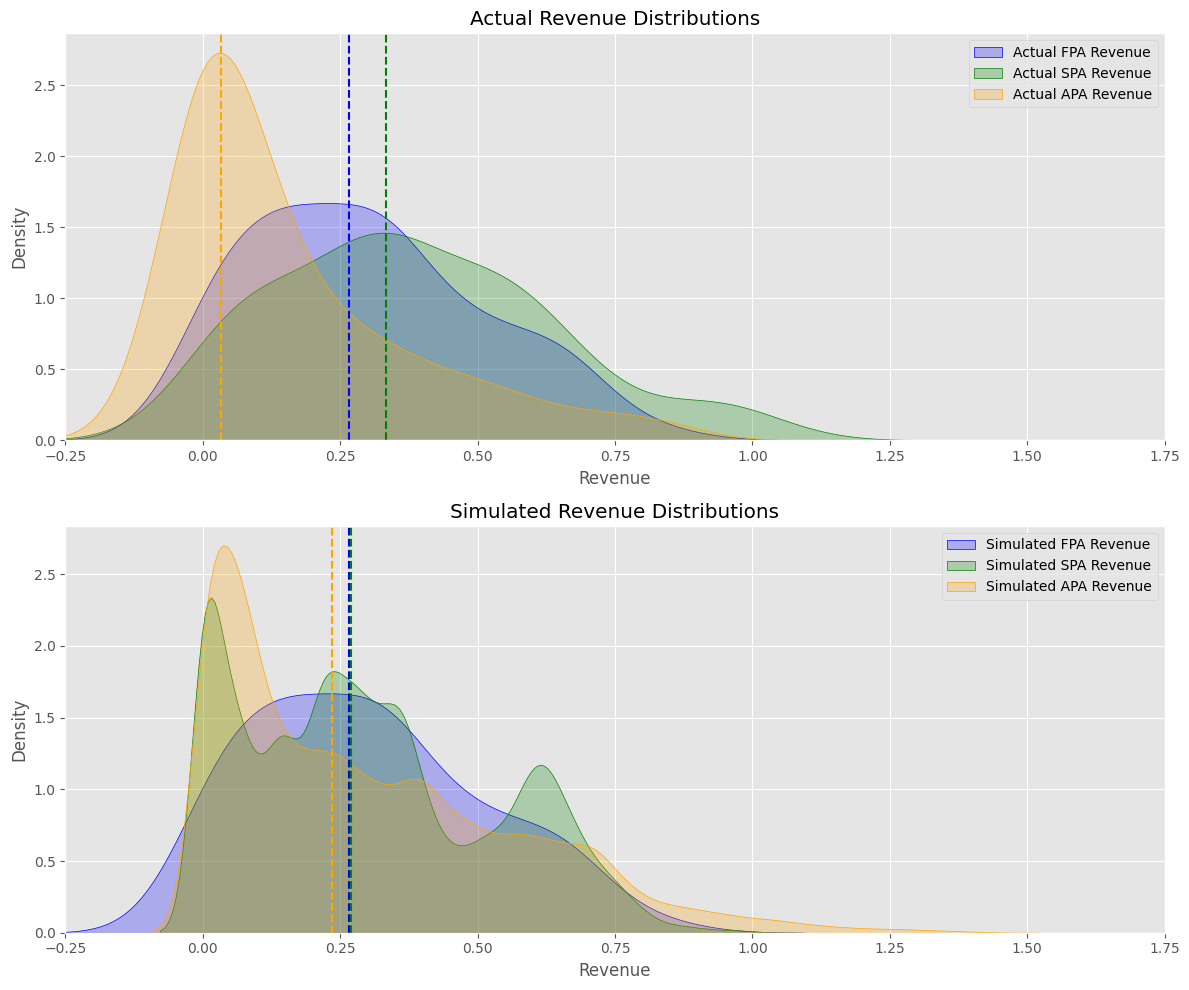

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import gaussian_kde, norm
plt.style.use('ggplot')
import warnings
warnings.filterwarnings('ignore')

# Load and clean All-Pay Auction data
def load_and_clean_all_pay_data(filepath):
    data = pd.read_csv(filepath)
    cleaned_data = data[(data['matched_info'] == 'yes') & 
                        (data['bid_ap'] >= 0) &
                        (data['bid_ap'] <= data['value_ap']) &
                        (data['even_month'] == 'no') &
                        (data['value_ap'] <= 30) &
                        (data['value_ap'] >= 0)].copy()
    cleaned_data['bid_ap'] = cleaned_data['bid_ap'] / 30  # Normalize to 0-1 range
    cleaned_data['value_ap'] = cleaned_data['value_ap'] / 30  # Normalize to 0-1 range
    return cleaned_data

# Load and clean First-Price Auction data
def load_and_clean_first_price_data(filepath):
    data = pd.read_csv(filepath)
    cleaned_data = data[(data['matched_info'] == 'yes') & 
                        (data['bid_fp'] >= 0) &
                        (data['bid_fp'] <= 30) &
                        (data['even_month'] == 'no') &
                        (data['value_fp'] <= 30) &
                        (data['value_fp'] >= 0)].copy()
    cleaned_data['bid_fp'] = cleaned_data['bid_fp'] / 30  # Normalize to 0-1 range
    cleaned_data['value_fp'] = cleaned_data['value_fp'] / 30  # Normalize to 0-1 range
    return cleaned_data

# Load and clean Second-Price Auction data
def load_and_clean_second_price_data(filepath):
    data = pd.read_csv(filepath)
    cleaned_data = data[(data['matched_info'] == 'yes') & 
                        (data['bid_sp'] >= 0) &
                        (data['bid_sp'] <= data['value_sp']) &
                        (data['even_month'] == 'no') &
                        (data['value_sp'] <= 30) &
                        (data['value_sp'] >= 0)].copy()
    cleaned_data['bid_sp'] = cleaned_data['bid_sp'] / 30  # Normalize to 0-1 range
    cleaned_data['value_sp'] = cleaned_data['value_sp'] / 30  # Normalize to 0-1 range
    return cleaned_data

# Perform linear regression between bids and valuations for FPA (no longer needed for FPA revenue)
def get_fpa_bidding_function(fpa_data):
    # Perform linear regression between valuations and bids
    X = sm.add_constant(fpa_data['value_fp'])
    model = sm.OLS(fpa_data['bid_fp'], X).fit()
    intercept, slope = model.params

    # Create a bidding function from the regression
    fpa_bidding_func = lambda v: intercept + slope * v
    return fpa_bidding_func, model

# Sample bids based on valuation and median-95th-5th percentiles
def sample_bids_given_valuation(valuations, median_func, p5_func, p95_func):
    # Get the corresponding bid values based on the valuation
    median_bids = median_func(valuations)
    p5_bids = p5_func(valuations)
    p95_bids = p95_func(valuations)

    # Sample from normal distribution constrained by 5th and 95th percentiles
    std_dev = (p95_bids - p5_bids) / 4  # Approximation: use range as 4 standard deviations
    sampled_bids = np.clip(norm.rvs(loc=median_bids, scale=std_dev), p5_bids, p95_bids)
    return sampled_bids

# Sample values and use the simulated bidding functions to generate bids and revenues
def simulate_revenue_distribution(valuation_dist, median_func, p5_func, p95_func, auction_type, num_samples=10000, num_matches=10):
    valuations = valuation_dist.resample(num_samples)[0]
    bids = sample_bids_given_valuation(valuations, median_func, p5_func, p95_func)
    total_revenue = []

    for _ in range(num_matches):  # Repeat the matching process `num_matches` times
        pairs = np.random.choice(num_samples, (num_samples // 2, 2), replace=False)
        
        if auction_type == 'SPA':
            revenue = np.minimum(bids[pairs[:, 0]], bids[pairs[:, 1]])  # Second-highest bid
        elif auction_type == 'APA':
            revenue = bids[pairs[:, 0]] + bids[pairs[:, 1]]  # Sum of both bids in All-Pay
        else:
            raise ValueError("Unknown auction type")
        
        total_revenue.extend(revenue)

    return np.array(total_revenue)

# Plot function for simulated and actual revenue distributions
def plot_revenue_distributions(fpa_revenue, spa_revenue, apa_revenue, fpa_actual, spa_actual, apa_actual):
    plt.figure(figsize=(12, 10))

    # (1) Actual Seller Revenue Distribution
    plt.subplot(2, 1, 1)
    sns.kdeplot(fpa_actual, label='Actual FPA Revenue', shade=True, color='blue')
    sns.kdeplot(spa_actual, label='Actual SPA Revenue', shade=True, color='green')
    sns.kdeplot(apa_actual, label='Actual APA Revenue', shade=True, color='orange')
    plt.axvline(np.median(fpa_actual), color='blue', linestyle='--')
    plt.axvline(np.median(spa_actual), color='green', linestyle='--')
    plt.axvline(np.median(apa_actual), color='orange', linestyle='--')
    plt.title(f'Actual Revenue Distributions')
    plt.xlabel('Revenue')
    plt.ylabel('Density')
    plt.xlim([-0.25, 1.75])  # Equal spacing on the x-axis
    plt.legend()

    # (2) Simulated Seller Revenue Distribution
    plt.subplot(2, 1, 2)
    sns.kdeplot(fpa_revenue, label='Simulated FPA Revenue', shade=True, color='blue')
    sns.kdeplot(spa_revenue, label='Simulated SPA Revenue', shade=True, color='green')
    sns.kdeplot(apa_revenue, label='Simulated APA Revenue', shade=True, color='orange')
    plt.axvline(np.median(fpa_revenue), color='blue', linestyle='--')
    plt.axvline(np.median(spa_revenue), color='green', linestyle='--')
    plt.axvline(np.median(apa_revenue), color='orange', linestyle='--')
    plt.title(f'Simulated Revenue Distributions')
    plt.xlabel('Revenue')
    plt.ylabel('Density')
    plt.xlim([-0.25, 1.75])  # Equal spacing on the x-axis
    plt.legend()

    plt.tight_layout()
    plt.show()

# Main flow
filepath = 'clean_kaplan_data.csv'

# Load actual data for each auction type
all_pay_data = load_and_clean_all_pay_data(filepath)
first_price_data = load_and_clean_first_price_data(filepath)
second_price_data = load_and_clean_second_price_data(filepath)

# Ensure there are enough elements in the KDE
if len(first_price_data['value_fp']) > 1:
    kde_fp = gaussian_kde(first_price_data['value_fp'].values)
else:
    raise ValueError("Not enough data for First Price Auction after filtering.")

# Interpolation function for SPA
spa_bidding_median_func = lambda v: np.interp(v, np.linspace(0, 1, len(learned_bidding_function_spa['median'])), learned_bidding_function_spa['median'])
spa_bidding_p5_func = lambda v: np.interp(v, np.linspace(0, 1, len(learned_bidding_function_spa['5th'])), learned_bidding_function_spa['5th'])
spa_bidding_p95_func = lambda v: np.interp(v, np.linspace(0, 1, len(learned_bidding_function_spa['95th'])), learned_bidding_function_spa['95th'])

# Interpolation function for APA
apa_bidding_median_func = lambda v: np.interp(v, np.linspace(0, 1, len(learned_bidding_function_apa['median'])), learned_bidding_function_apa['median'])
apa_bidding_p5_func = lambda v: np.interp(v, np.linspace(0, 1, len(learned_bidding_function_apa['5th'])), learned_bidding_function_apa['5th'])
apa_bidding_p95_func = lambda v: np.interp(v, np.linspace(0, 1, len(learned_bidding_function_apa['95th'])), learned_bidding_function_apa['95th'])

# Simulating seller revenues for SPA and APA with 10 matches per pair
spa_revenue = simulate_revenue_distribution(kde_fp, spa_bidding_median_func, spa_bidding_p5_func, spa_bidding_p95_func, 'SPA', num_samples=10000, num_matches=10)
apa_revenue = simulate_revenue_distribution(kde_fp, apa_bidding_median_func, apa_bidding_p5_func, apa_bidding_p95_func, 'APA', num_samples=10000, num_matches=10)

# For FPA, use actual bids to calculate revenue (no simulation needed)
fpa_actual_revenue = np.maximum(first_price_data['bid_fp'].values, first_price_data['bid_fp'].values)

# Calculate actual revenues from the dataset
actual_fpa_revenue = first_price_data['bid_fp'].dropna().values.flatten()
actual_spa_revenue = second_price_data['bid_sp'].dropna().values.flatten()
actual_apa_revenue = all_pay_data['bid_ap'].dropna().values.flatten()

# Plot the results
plot_revenue_distributions(actual_fpa_revenue, spa_revenue, apa_revenue, actual_fpa_revenue, actual_spa_revenue, actual_apa_revenue)

# EDA

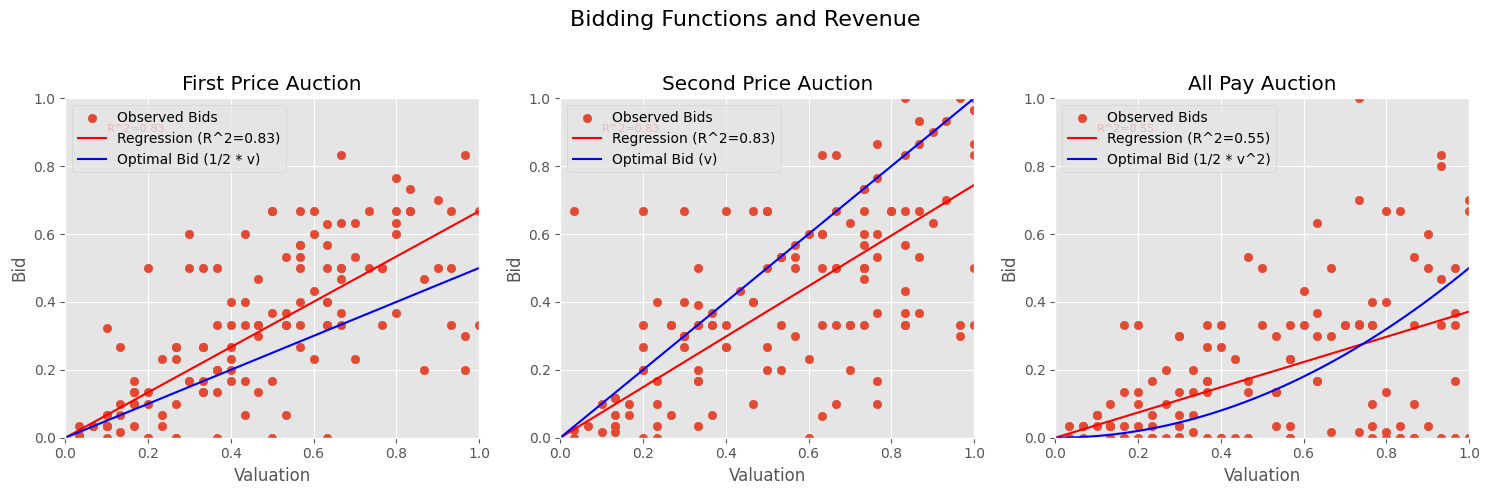

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
plt.style.use('ggplot')
import warnings
warnings.filterwarnings('ignore')

def load_and_clean_data(filepath):
    data = pd.read_csv(filepath)
    filtered_data = data[(data['matched_info'] == 'yes') & (data[['bid_fp', 'bid_sp', 'bid_ap']] <= 30).all(axis=1)].copy()
    return filtered_data

def normalize_data(filtered_data):
    val_min = 0
    val_max = 30
    filtered_data[['value_fp', 'value_sp', 'value_ap', 'bid_fp', 'bid_sp', 'bid_ap']] = \
        (filtered_data[['value_fp', 'value_sp', 'value_ap', 'bid_fp', 'bid_sp', 'bid_ap']] - val_min) / (val_max - val_min)
    return filtered_data

def remove_bids_above_one(data):
    return data[(data[['bid_fp', 'bid_sp', 'bid_ap']] <= 1.0).all(axis=1)]

def create_cross_join(data):
    paired_data = data.assign(key=1).merge(data.assign(key=1), on='key').query('name_x != name_y').drop(columns='key')
    paired_data = paired_data[paired_data[['name_x', 'name_y']].apply(frozenset, axis=1).duplicated(keep='first') == False]
    return paired_data

def simulate_auction(df):
    df['fpa_winner'] = np.where(df['bid_fp_x'] > df['bid_fp_y'], df['name_x'], df['name_y'])
    df['fpa_payment'] = np.where(df['bid_fp_x'] > df['bid_fp_y'], df['bid_fp_x'], df['bid_fp_y'])
    df['fpa_winner_valuation'] = np.where(df['fpa_winner'] == df['name_x'], df['value_fp_x'], df['value_fp_y'])
    
    df['spa_winner'] = np.where(df['bid_sp_x'] > df['bid_sp_y'], df['name_x'], df['name_y'])
    df['spa_payment'] = np.where(df['bid_sp_x'] > df['bid_sp_y'], df['bid_sp_y'], df['bid_sp_x'])
    df['spa_winner_valuation'] = np.where(df['spa_winner'] == df['name_x'], df['value_sp_x'], df['value_sp_y'])
    
    df['apa_winner'] = np.where(df['bid_ap_x'] > df['bid_ap_y'], df['name_x'], df['name_y'])
    df['apa_payment'] = df['bid_ap_x'] + df['bid_ap_y']
    df['apa_winner_valuation'] = np.where(df['apa_winner'] == df['name_x'], df['value_ap_x'], df['value_ap_y'])

    df['fpa_surplus'] = df['fpa_winner_valuation'] - df['fpa_payment']
    df['spa_surplus'] = df['spa_winner_valuation'] - df['spa_payment']
    df['apa_surplus'] = df['apa_winner_valuation'] - df['apa_payment']

    return df

def add_regression_line(ax, v, b):
    model = sm.OLS(b, v).fit()

    v_range = np.linspace(0, 1, 100)
    b_pred = model.predict(v_range)
    
    ax.plot(v_range, b_pred, color='red', label=f'Regression (R^2={model.rsquared:.2f})')
    ax.text(0.1, 0.9, f'R^2={model.rsquared:.2f}', transform=ax.transAxes, fontsize=8, color='red')

def plot_bids_vs_valuations(data, results):
    plt.figure(figsize=(15, 5))
    plt.suptitle('Bidding Functions and Revenue', fontsize=16)

    v_range = np.linspace(0, 1, 100)

    # (1) First Price Auction
    plt.subplot(1, 3, 1)
    plt.scatter(data['value_fp'], data['bid_fp'], label='Observed Bids')
    add_regression_line(plt.gca(), data['value_fp'], data['bid_fp'])
    plt.plot(v_range, 0.5 * v_range, color='blue', label='Optimal Bid (1/2 * v)')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.title('First Price Auction')
    plt.xlabel('Valuation')
    plt.ylabel('Bid')
    plt.legend()

    # (2) Second Price Auction
    plt.subplot(1, 3, 2)
    plt.scatter(data['value_sp'], data['bid_sp'], label='Observed Bids')
    add_regression_line(plt.gca(), data['value_sp'], data['bid_sp'])
    plt.plot(v_range, v_range, color='blue', label='Optimal Bid (v)')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.title('Second Price Auction')
    plt.xlabel('Valuation')
    plt.ylabel('Bid')
    plt.legend()

    # (3) All Pay Auction
    plt.subplot(1, 3, 3)
    plt.scatter(data['value_ap'], data['bid_ap'], label='Observed Bids')
    add_regression_line(plt.gca(), data['value_ap'], data['bid_ap'])
    plt.plot(v_range, 0.5 * v_range ** 2, color='blue', label='Optimal Bid (1/2 * v^2)')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.title('All Pay Auction')
    plt.xlabel('Valuation')
    plt.ylabel('Bid')
    plt.legend()

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Main flow
filepath = '/home/pp712/double-auctions/code/14_simple/clean_kaplan_data.csv'
filtered_data = load_and_clean_data(filepath)
normalized_data = normalize_data(filtered_data)
normalized_data = remove_bids_above_one(normalized_data)
paired_data = create_cross_join(normalized_data)
results = simulate_auction(paired_data)
plot_bids_vs_valuations(normalized_data, results)
